In [1]:
# ## Imports

#3 The required libraries were imported for data handling, numerical calculations, and visualization.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Preparation

The dataset was loaded, filtered for JFK Airport, and transformed into a proper time series structure. The "Total Passengers" variable was selected as the target series for centered moving average analysis.

In [ ]:
# Load the dataset 
df = pd.read_csv('../data/air-passenger-traffic-per-month-port-authority-of-ny-nj-beginning-1977.csv')

# Filtered JFK observation
df_jfk = df[df['Airport Code'] == 'JFK'].copy()

# Map month names to numerical values

month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Agu': 8, 
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

df['Month'] = df['Month'].astype(str).str.strip().map(month_map)


In [2]:
# Create prooer datetime 
df['Date'] = pd.to_datetime(
    dict(year=df['Year'], month=df['Month'], day=1),
    errors="coerce"
)
# Remove invalid dates
df = df.dropna(subset=["Date"]).copy()

# Aggregate to monthly total
df_monthly = (
    df.groupby(["Date"])["Total Passengers"]
    .sum()
    .sort_index()
    .to_frame()
)

# Final time series
ts= df_monthly['Total Passengers']

print(ts.head())
print(ts.tail())
print(ts.index.is_unique)
print(ts.shape)



NameError: name 'df' is not defined

## Workin DataFrame

A new dataframe was create was created to store the actual values together with centered moving avarage results. 


In [ ]:
df_cma = pd.DataFrame({'Actual': ts.copy()})
df_cma.head()

,Actual
Date,
1977-01-01,3121945
1977-02-01,2769063
1977-03-01,3254605
1977-04-01,3492036
1977-05-01,3563483


## 2-Period Centered Moving Avarege

For the 2-period centered mobing average, a 2-period moving average was first calculated. 
Since the window length is even, the values fall between two time periods. To align them with actual observation, the moving averages were centered by taking another 2-period average.
This procedure produces a centered mobing average series that better aligned with the time index. 

In [ ]:
# step 1 : calculate  2-period moving average 
df_cma['MA_2_raw'] = df_cma['Actual'].rolling(window=2).mean()

# Step 2: center the 2-period mobing average
df_cma['CMA_2'] = df_cma['MA_2_raw'].rolling(window=2).mean()

df_cma.head(10)

,Actual,MA_2_raw,CMA_2
Date,,,
1977-01-01,3121945,NaN,NaN
1977-02-01,2769063,2945504.0,NaN
1977-03-01,3254605,3011834.0,2978669.00
1977-04-01,3492036,3373320.5,3192577.25
1977-05-01,3563483,3527759.5,3450540.00
1977-06-01,3845727,3704605.0,3616182.25
1977-07-01,4314472,4080099.5,3892352.25
1977-09-01,3866672,4090572.0,4085335.75
1977-10-01,3778207,3822439.5,3956505.75


## 3-Period Centered Moving Average

A 3-period centered moving average was calculated directly by using a centered rolling window. Since the window length is odd, the average naturally aligns with the middle observation.

In [ ]:
df_cma['CMA_3'] = df_cma['Actual'].rolling(window=3, center=True).mean()

df_cma.head(10)

,Actual,MA_2_raw,CMA_2,CMA_3
Date,,,,
1977-01-01,3121945,NaN,NaN,NaN
1977-02-01,2769063,2945504.0,NaN,3.048538e+06
1977-03-01,3254605,3011834.0,2978669.00,3.171901e+06
1977-04-01,3492036,3373320.5,3192577.25,3.436708e+06
1977-05-01,3563483,3527759.5,3450540.00,3.633749e+06
1977-06-01,3845727,3704605.0,3616182.25,3.907894e+06
1977-07-01,4314472,4080099.5,3892352.25,4.008957e+06
1977-09-01,3866672,4090572.0,4085335.75,3.986450e+06
1977-10-01,3778207,3822439.5,3956505.75,3.682399e+06


## Visualization of Centered Moving Averages

The graph shows the actual passenger values together with the 2-period and 3-period centered moving averages.

Centered moving averages smooth the series and help reveal the underlying movement more clearly by reducing short-term fluctuations.

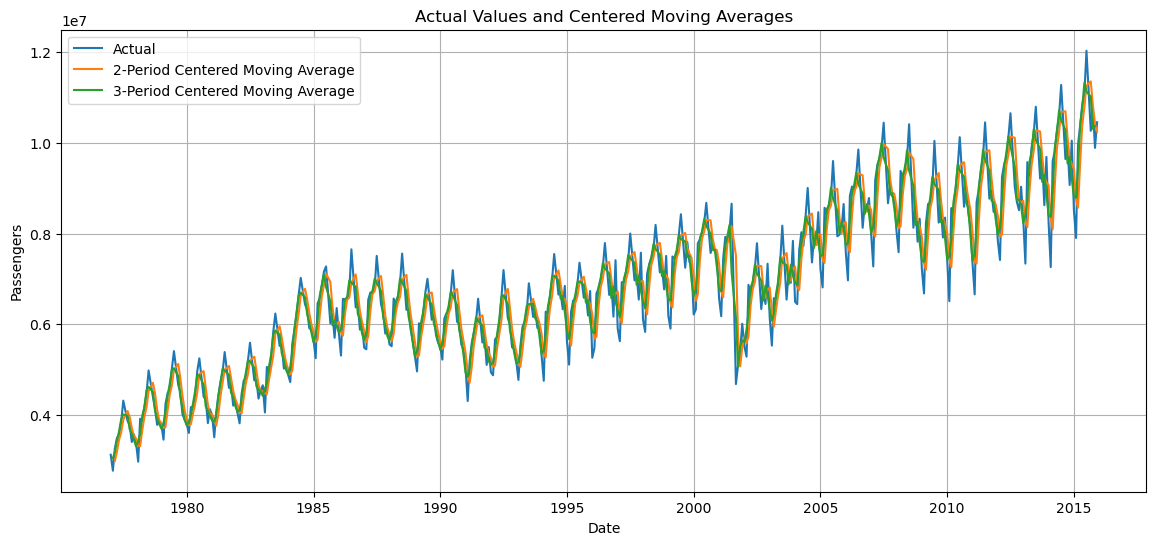

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df_cma.index, df_cma['Actual'], label='Actual')
plt.plot(df_cma.index, df_cma['CMA_2'], label='2-Period Centered Moving Average')
plt.plot(df_cma.index, df_cma['CMA_3'], label='3-Period Centered Moving Average')

plt.title('Actual Values and Centered Moving Averages')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

## Recent Period Comparison

A closer plot of the last 36 periods was created to better examine how the centered moving average follow the actual series in recent years.

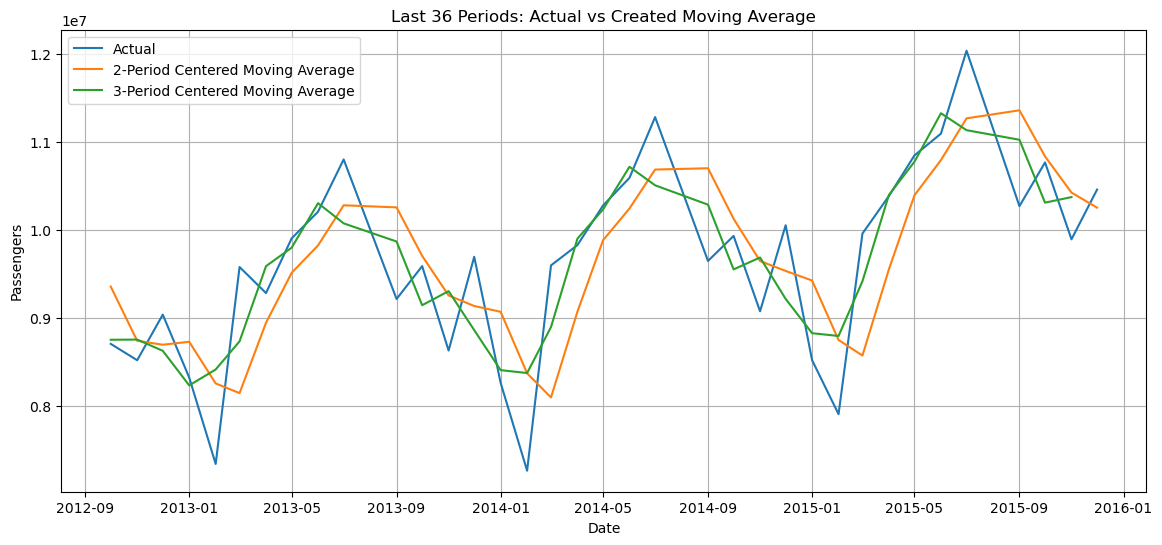

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df_cma.index[-36:], df_cma['Actual'].iloc[-36:], label='Actual')
plt.plot(df_cma.index[-36:], df_cma['CMA_2'].iloc[-36:], label='2-Period Centered Moving Average')
plt.plot(df_cma.index[-36:], df_cma['CMA_3'].iloc[-36:], label='3-Period Centered Moving Average')

plt.title('Last 36 Periods: Actual vs Created Moving Average')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

Missing values were removed before plotting since centered moving averages do not produce values at the boundaries of the dataset. This ensures a correct and meaningful visualization.

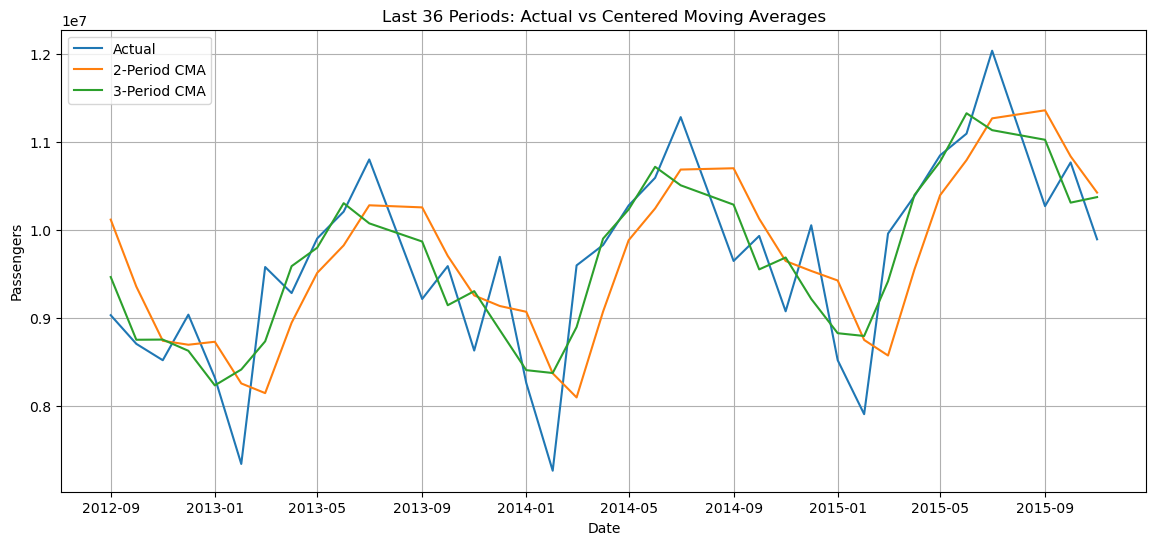

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(df_plot.index[-36:], df_plot["Actual"].iloc[-36:], label="Actual")
plt.plot(df_plot.index[-36:], df_plot["CMA_2"].iloc[-36:], label="2-Period CMA")
plt.plot(df_plot.index[-36:], df_plot["CMA_3"].iloc[-36:], label="3-Period CMA")

plt.title("Last 36 Periods: Actual vs Centered Moving Averages")
plt.xlabel("Date")
plt.ylabel("Passengers")

plt.legend()
plt.grid(True)
plt.show()